<a href="https://colab.research.google.com/github/CharlotteHoyt/Barbie-Data-Visualization/blob/main/CSS173_GW3_Towards_Finalizing_the_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CSS173 GW3: Towards Finalizing the Analysis**

**Group Members:** Abby Hoyt, Charlotte Hoyt, Jin Cho, and Somya Prasad

<br>

**Group Topic:** Resumes/Hiring Outcomes

<br>

**Brief Project Overview:**
- We want to explore how demographics and resume information affect hiring decisions.
- We are asking the question, "Who gets hired, and why might this be the case?"
- We will be considering employability patterns based on personal information, education history, previous work experience, and technical skills.

<br>

**Analysis Questions:**
- What are the characteristics/attributes of employable job applicants?
  - What demographic "combinations" are most likely to be employed?
  - What demographics are the least represented?

<br>

- How does education level influence employment and salary?
  - Do those with higher levels of education get paid more?
  - Are those with higher levels of education more likely to be employed? (Even with fewer computer skills, fewer years coding, or fewer years coding professionally?)
  - What is the "value" of a degree?

<br>

- How does demographic information (age, gender, etc.) relate to the number of "computer skills" a person knows?
  - Do younger people have more "computer skills?"
  - Have younger people been coding longer?

## **Working Data Pipeline**

The main dataset we will be using is [70k+ Job Applicants Data (Human Resource)](https://www.kaggle.com/datasets/ayushtankha/70k-job-applicants-data-human-resource) from Kaggle. This datset contains a variety of information about computing professional job applicants as well as their employability levels/status.

**Load the Data:**

In [ ]:
# Load data and mount to Google Drive.
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

first_dataset = pd.read_csv("/content/drive/My Drive/CSS173 Datasets/stackoverflow_full.csv")
first_dataset.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Unnamed: 0,Age,Accessibility,EdLevel,Employment,Gender,MentalHealth,MainBranch,YearsCode,YearsCodePro,Country,PreviousSalary,HaveWorkedWith,ComputerSkills,Employed
0,0,<35,No,Master,1,Man,No,Dev,7,4,Sweden,51552.0,C++;Python;Git;PostgreSQL,4,0
1,1,<35,No,Undergraduate,1,Man,No,Dev,12,5,Spain,46482.0,Bash/Shell;HTML/CSS;JavaScript;Node.js;SQL;Typ...,12,1
2,2,<35,No,Master,1,Man,No,Dev,15,6,Germany,77290.0,C;C++;Java;Perl;Ruby;Git;Ruby on Rails,7,0
3,3,<35,No,Undergraduate,1,Man,No,Dev,9,6,Canada,46135.0,Bash/Shell;HTML/CSS;JavaScript;PHP;Ruby;SQL;Gi...,13,0
4,4,>35,No,PhD,0,Man,No,NotDev,40,30,Singapore,160932.0,C++;Python,2,0


**Filter the Data:**

In [ ]:
# Drop unneeded/confusing columns from the first datset.
first_dataset.drop(['MentalHealth', 'Accessibility', 'Unnamed: 0'], axis = 1, inplace = True)
first_dataset.head()

,Age,EdLevel,Employment,Gender,MainBranch,YearsCode,YearsCodePro,Country,PreviousSalary,HaveWorkedWith,ComputerSkills,Employed
0,<35,Master,1,Man,Dev,7,4,Sweden,51552.0,C++;Python;Git;PostgreSQL,4,0
1,<35,Undergraduate,1,Man,Dev,12,5,Spain,46482.0,Bash/Shell;HTML/CSS;JavaScript;Node.js;SQL;Typ...,12,1
2,<35,Master,1,Man,Dev,15,6,Germany,77290.0,C;C++;Java;Perl;Ruby;Git;Ruby on Rails,7,0
3,<35,Undergraduate,1,Man,Dev,9,6,Canada,46135.0,Bash/Shell;HTML/CSS;JavaScript;PHP;Ruby;SQL;Gi...,13,0
4,>35,PhD,0,Man,NotDev,40,30,Singapore,160932.0,C++;Python,2,0


## **At Least Three Concrete Computations**

#### **Computation 1: Mean, Median, Minumum, Maximum, Range, and Standard Deviation of Important Columns**

In [ ]:
# Determine important columns.
important_cols = ["YearsCode", "YearsCodePro", "ComputerSkills", "PreviousSalary"]

# Get mean, median, minimum, maximum, range, and standard deviation of important columns.
for col in important_cols:
  print(f"{col}:")
  print(f"* Mean: {first_dataset[col].mean()}")
  print(f"* Median: {first_dataset[col].median()}")
  print(f"* Min: {first_dataset[col].min()}")
  print(f"* Max: {first_dataset[col].max()}")
  print(f"* Range: {first_dataset[col].max() - first_dataset[col].min()}")
  print(f"* Standard Deviation: {first_dataset[col].std()}\n")

# Determine how many applicants are employed/not employed.
employed_counts = first_dataset["Employed"].value_counts()
print(employed_counts)

YearsCode:
* Mean: 14.218902289619123
* Median: 12.0
* Min: 0
* Max: 50
* Range: 50
* Standard Deviation: 9.405172021522803

YearsCodePro:
* Mean: 9.098377392393346
* Median: 7.0
* Min: 0
* Max: 50
* Range: 50
* Standard Deviation: 7.960201390496356

ComputerSkills:
* Mean: 13.428221393373445
* Median: 13.0
* Min: 0
* Max: 107
* Range: 107
* Standard Deviation: 7.057834667828135

PreviousSalary:
* Mean: 67750.2606109281
* Median: 57588.0
* Min: 1.0
* Max: 224000.0
* Range: 223999.0
* Standard Deviation: 49488.142117662144

Employed
1    39392
0    34070
Name: count, dtype: int64


**Interpretation of Computation 1:**
* The mean years coding is ~14.22. The median is 12. Applicants with many years of coding experience (e.g., the max of 50) may be pulling the average slightly.
* The mean number of years coding professionally is ~9.10. It makes sense that people have been coding longer than they have been coding professionally.
* The average applicant reports about 5 more years coding than years coding professionally, suggesting that people may have began coding before they were employed as a computing professional.
* The range of computer skills is very wide (0 to 107), showing a lot of variation in how much technical knowledge applicants report. (107 computer skills seems like a lot!)
* The median number of computer skills is 13 and the mean is ~13.43. These are close, but since the mean > median, it means the data is skewed slightly to the right, or, that the data is slightly concentrated to the left.
* The mean salary is higher than the median salary, meaning high earners may be pulling the average. This wealth disparity is also perhaps illustrated by the range, where the minimum is 1.0 and the maximum is 224,000.0. There is a big difference between these values!





#### **Computation 2: Correlation Matrix (Simple Relationship Summary)**

                Employment  YearsCode  YearsCodePro  PreviousSalary  \
Employment        1.000000  -0.080691     -0.092917        0.036980   
YearsCode        -0.080691   1.000000      0.901073        0.390855   
YearsCodePro     -0.092917   0.901073      1.000000        0.393615   
PreviousSalary    0.036980   0.390855      0.393615        1.000000   
ComputerSkills   -0.037904  -0.020460     -0.012838        0.030362   
Employed         -0.012142  -0.003756      0.002886        0.000379   

                ComputerSkills  Employed  
Employment           -0.037904 -0.012142  
YearsCode            -0.020460 -0.003756  
YearsCodePro         -0.012838  0.002886  
PreviousSalary        0.030362  0.000379  
ComputerSkills        1.000000  0.585545  
Employed              0.585545  1.000000  


Heatmap of Above Correlation Matrix:


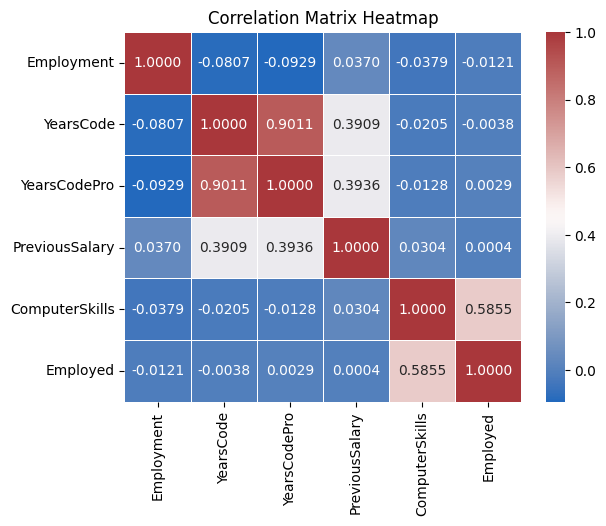

In [ ]:
# Create a correlation matrix for numeric columns in the first datset.
correlation_matrix = first_dataset.corr(numeric_only = True)
print(correlation_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap to visualize the correlation matrix.
print("\n\nHeatmap of Above Correlation Matrix:")
sns.heatmap(correlation_matrix, annot = True, cmap = "vlag", fmt = ".4f", linewidths = 0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

**Interpretation of Computation 2:**
* A lot of the variables do not show a strong correlation, meaning that there is no meaningful relationship between many of the columns.
* However, there is a strong positive correlation between years coding in total and years coding professionally.
* There is a moderate correlation between years of coding experience (both YearsCode and YearsCodePro) and previous salary. This might mean that the longer an applicant has been coding, the higher their previous salary was. However, this isn't a highly predictable, linear relationship.
* The number of computer skills an applicant reports has a stronger relationship with employment status than years of coding experience.
* Previous salary does not have a meaningful relationship with employment status.




#### **Computation 3: Counts Across Categories**

We will be analyzing our categorical data twice. First, we will look at the demographics and skills of ALL applicants. Then, we will look at the demographics and skills of only EMPLOYED applicants. By analyzing all and employed applicants, we may learn about the traits and skills of employable individuals.

**Computation 3 Part 1: Charts illustrating the most common demographics/skills of ALL applicants.**

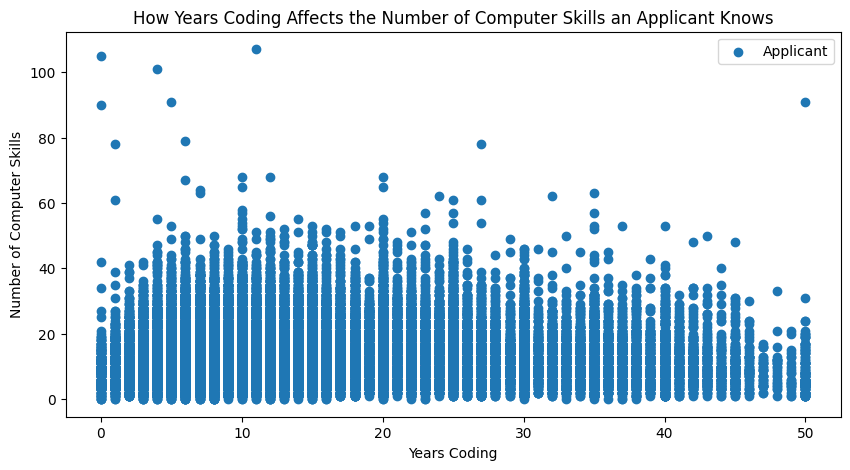

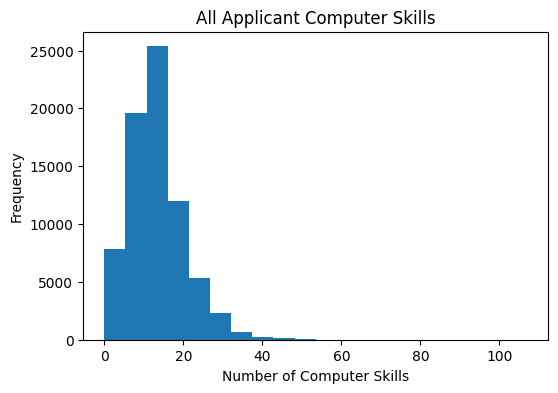

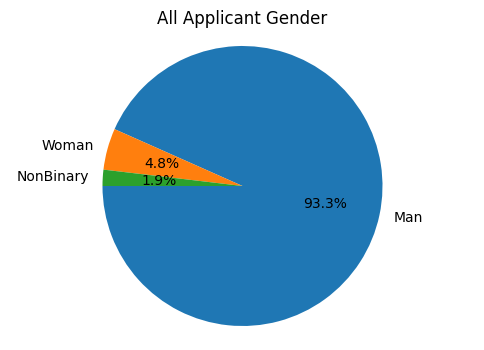

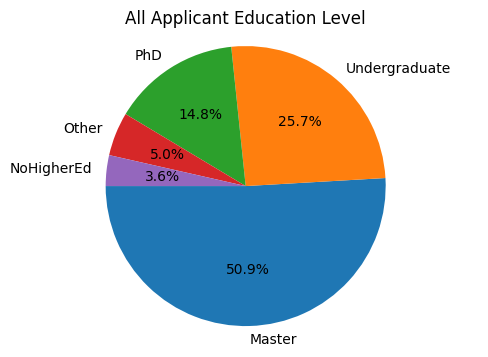

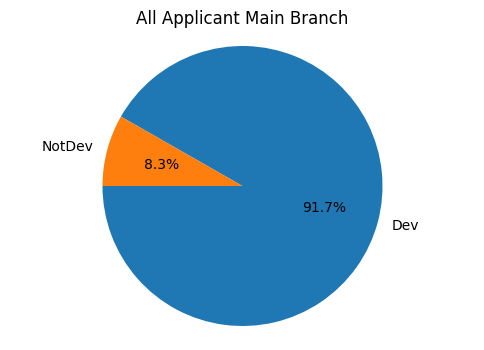

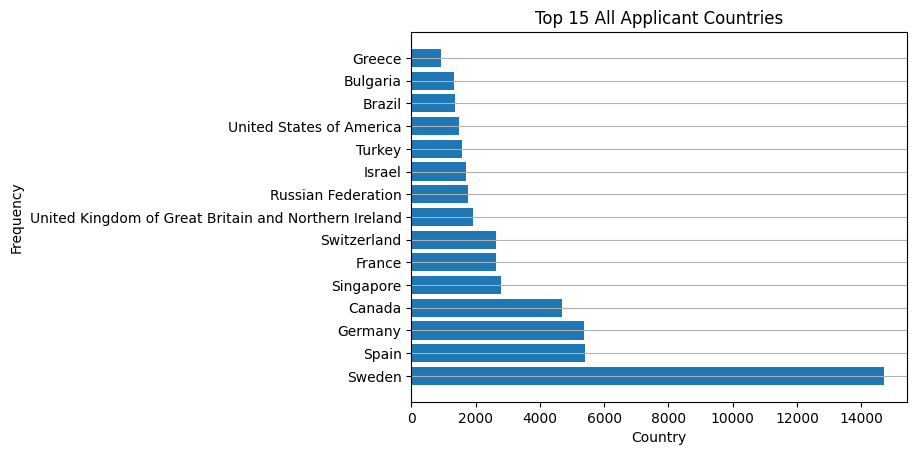

In [ ]:
import matplotlib.pyplot as plt

# YEARS CODE VS. COMPUTER SKILLS
# Plot the data and add labels for a scatter plot of YearsCode vs. Computer Skills.
plt.figure(figsize = (10, 5))
plt.scatter(first_dataset['YearsCode'], first_dataset['ComputerSkills'], label = "Applicant")
plt.xlabel("Years Coding")
plt.ylabel("Number of Computer Skills")
plt.legend()
plt.title("How Years Coding Affects the Number of Computer Skills an Applicant Knows")
plt.show()


# COMPUTER SKILLS
# Plot computer skills bar chart.
plt.figure(figsize = (6, 4))
plt.hist(first_dataset['ComputerSkills'], bins = 20)
plt.title("All Applicant Computer Skills")
plt.xlabel("Number of Computer Skills")
plt.ylabel("Frequency")
plt.show()


# GENDER
# Get gender columns and counts.
gender = first_dataset['Gender'].unique()
gender_counts = first_dataset['Gender'].value_counts()

# Plot gender pie chart.
plt.figure(figsize = (6, 4))
plt.pie(gender_counts, labels = gender, autopct = "%1.1f%%", shadow = False, startangle = 180)
plt.axis("equal")
plt.title("All Applicant Gender")
plt.show()


# EDUCATION LEVEL
# Get education level columns and counts.
ed_level = first_dataset['EdLevel'].unique()
ed_level_counts = first_dataset['EdLevel'].value_counts()

# Plot education level pie chart.
plt.figure(figsize = (6, 4))
plt.pie(ed_level_counts, labels = ed_level, autopct = "%1.1f%%", shadow = False, startangle = 180)
plt.axis("equal")
plt.title("All Applicant Education Level")
plt.show()


# MAIN BRANCH
# Get main branch columns and counts.
main_branch = first_dataset['MainBranch'].unique()
main_branch_counts = first_dataset['MainBranch'].value_counts()

# Plot applicant main branch pie chart.
plt.figure(figsize = (6, 4))
plt.pie(main_branch_counts, labels = main_branch, autopct = "%1.1f%%", shadow = False, startangle = 180)
plt.axis("equal")
plt.title("All Applicant Main Branch")
plt.show()


# COUNTRY
# Get country columns and counts.
country = first_dataset['Country'].unique()
country_counts = first_dataset['Country'].value_counts()

# Sort countries numerically.
sorted_country_data = sorted(zip(country, country_counts), key = lambda x: x[1], reverse = True)
sorted_country, sorted_country_counts = zip(*sorted_country_data)

# Get just the top 15 most common countries in the dataset.
top_countries = []
top_country_counts = []

for i in range(15):
  top_countries.append(sorted_country[i])
  top_country_counts.append(sorted_country_counts[i])

# Plot top applicant countries bar chart.
fig, ax = plt.subplots()
ax.barh(top_countries, top_country_counts, align = "center")

ax.set_xlabel("Country")
ax.set_ylabel("Frequency")
ax.set_title("Top 15 All Applicant Countries")
ax.yaxis.grid(True)
plt.show()

**Computation 3 Part 1 Interpretation (ALL Applicants):**
* The number of years coding and the number of computer skills an applicant reports don't have a significant correlation or meaningful relationship.
  * The data points are spread pretty equally across the chart, with roughly equal density, meaning the variables are independent and can’t really be used to predict each other. Since the data is very uniform, there is no observable linear relationship or curve.
  * Some applicants with very low years of coding experience still report a relatively high number of computer skills.
  * Similarly, even applicants with many years of coding experience do not consistently report a high number of computer skills.
* Most applicants seem to have between 10 and 15 computer skills.
* Only 6.7% of applicants are non-binary or a woman. (This is not a very large percentage!)
* There are roughly half as many undergraduate applicants as master applicants, and about half as many PhD applicants as master applicants.
* Higher education dominated most applicant profiles, with only 3.6% of applicants reporting no higher education.
* Devs dominate the “MainBranch.” This means the majority of applicants are professional developers.
* We were surprised to see the top 15 applicant countries. It made us wonder what country the data might have been collected from, which took us back to the data card on Kaggle (where we downloaded the dataset). We learned the author of the dataset is from Paris, France, which may explain the high representation of European countries.  











**Computation 3 Part 2: Charts illustrating the most common demographics/skills of just EMPLOYED applicants.**

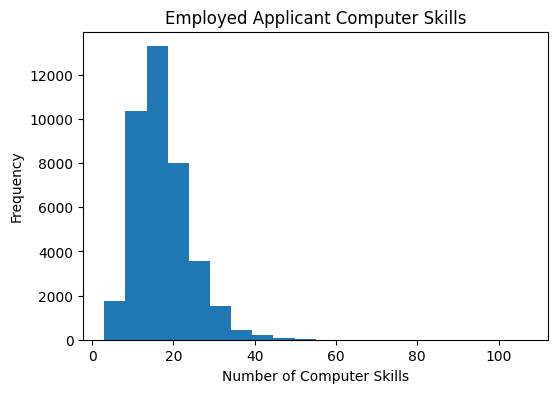

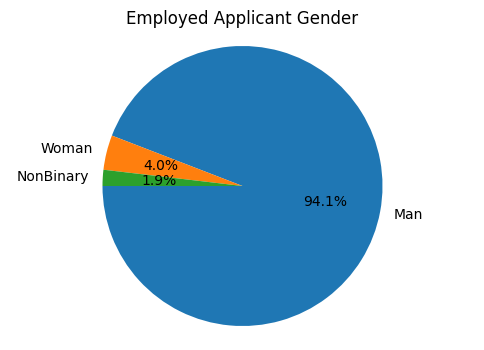

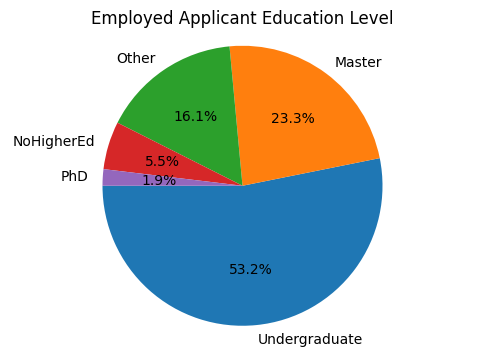

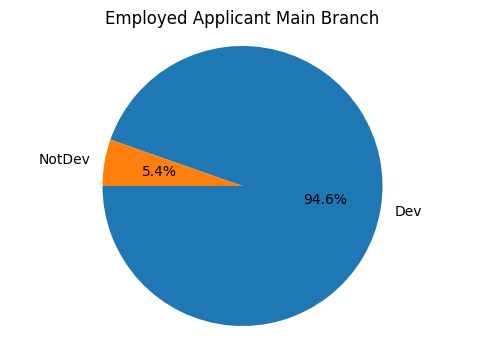

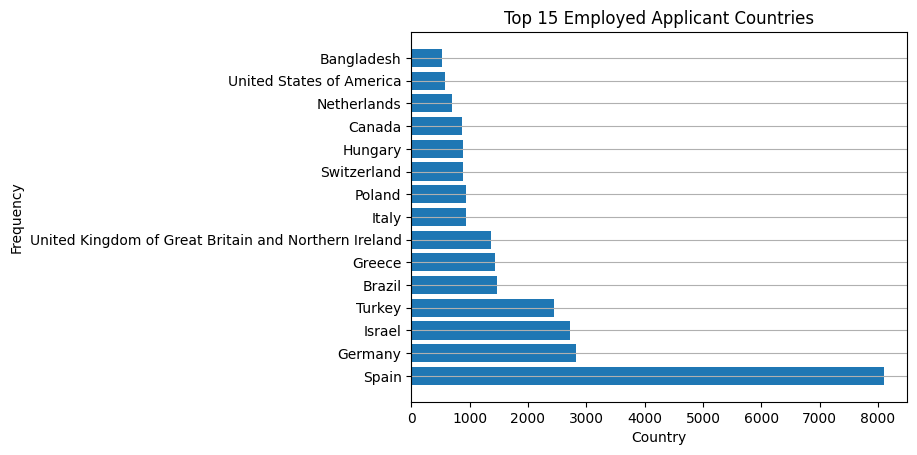

In [ ]:
# Filter the first datset to include only employed applicants.
boolean_mask = first_dataset['Employed'] == 1
employed_only_first_dataset = first_dataset[boolean_mask]
employed_only_first_dataset.head()


# COMPUTER SKILLS
# Plot computer skills bar chart.
plt.figure(figsize = (6, 4))
plt.hist(employed_only_first_dataset['ComputerSkills'], bins = 20)
plt.title("Employed Applicant Computer Skills")
plt.xlabel("Number of Computer Skills")
plt.ylabel("Frequency")
plt.show()


# GENDER
# Get gender columns and counts.
gender = employed_only_first_dataset['Gender'].unique()
gender_counts = employed_only_first_dataset['Gender'].value_counts()

# Plot gender pie chart.
plt.figure(figsize = (6, 4))
plt.pie(gender_counts, labels = gender, autopct = "%1.1f%%", shadow = False, startangle = 180)
plt.axis("equal")
plt.title("Employed Applicant Gender")
plt.show()


# EDUCATION LEVEL
# Get education level columns and counts.
ed_level = employed_only_first_dataset['EdLevel'].unique()
ed_level_counts = employed_only_first_dataset['EdLevel'].value_counts()

# Plot education level pie chart.
plt.figure(figsize = (6, 4))
plt.pie(ed_level_counts, labels = ed_level, autopct = "%1.1f%%", shadow = False, startangle = 180)
plt.axis("equal")
plt.title("Employed Applicant Education Level")
plt.show()


# MAIN BRANCH
# Get main branch columns and counts.
main_branch = employed_only_first_dataset['MainBranch'].unique()
main_branch_counts = employed_only_first_dataset['MainBranch'].value_counts()

# Plot applicant main branch pie chart.
plt.figure(figsize = (6, 4))
plt.pie(main_branch_counts, labels = main_branch, autopct = "%1.1f%%", shadow = False, startangle = 180)
plt.axis("equal")
plt.title("Employed Applicant Main Branch")
plt.show()


# COUNTRY
# Get country columns and counts.
country = employed_only_first_dataset['Country'].unique()
country_counts = employed_only_first_dataset['Country'].value_counts()

# Sort countries numerically.
sorted_country_data = sorted(zip(country, country_counts), key = lambda x: x[1], reverse = True)
sorted_country, sorted_country_counts = zip(*sorted_country_data)

# Get just the top 15 most common countries in the dataset.
top_countries = []
top_country_counts = []

for i in range(15):
  top_countries.append(sorted_country[i])
  top_country_counts.append(sorted_country_counts[i])

# Plot top applicant countries bar chart.
fig, ax = plt.subplots()
ax.barh(top_countries, top_country_counts, align = "center")

ax.set_xlabel("Country")
ax.set_ylabel("Frequency")
ax.set_title("Top 15 Employed Applicant Countries")
ax.yaxis.grid(True)
plt.show()

**Computation 3 Part Interpretations (EMPLOYED Applicants):**
* Employed applicants seem to know an average of 15 to 20 computer skills. This is a slight increase from the average number of computer skills known among all applicants.
* There are slightly fewer women/non-binary people who are employed. Representation here is similar to the distribution across all applicants, but there is about ~1% decrease between women/non-binary people in the dataset and those who are employed.
* While we found ~50% of ALL applicants have a master’s education level and ~26% had an undergraduate education level, this relationship essentially “flips” when we consider profiles of employed applicants, where ~53% of employed people have an undergraduates education level and ~23% of employed people have a master’s education level.
* Additionally, 5.5% of employed people did not pursue any higher education and only 1.9% of employed people hold a PhD.
* While 91.7% of all applicants were professional developers, 94.6% of employed people were professional developers.
* Finally, the top 15 applicant countries totally scrambles when we consider employed applicants vs. all applicants. For example, while Sweden had the most profiles in the dataset, Spain has the most employed computing professionals. There are still many European countries represented in the “top 15 countries” bar chart.

### **At Least One Preliminary Result**

In [ ]:
summary_statistics = first_dataset.describe()
print(summary_statistics)

         Employment     YearsCode  YearsCodePro  PreviousSalary  \
count  73462.000000  73462.000000  73462.000000    73462.000000   
mean       0.883096     14.218902      9.098377    67750.260611   
std        0.321308      9.405172      7.960201    49488.142118   
min        0.000000      0.000000      0.000000        1.000000   
25%        1.000000      7.000000      3.000000    28839.000000   
50%        1.000000     12.000000      7.000000    57588.000000   
75%        1.000000     20.000000     12.000000    95979.000000   
max        1.000000     50.000000     50.000000   224000.000000   

       ComputerSkills      Employed  
count    73462.000000  73462.000000  
mean        13.428221      0.536223  
std          7.057835      0.498690  
min          0.000000      0.000000  
25%          8.000000      0.000000  
50%         13.000000      1.000000  
75%         17.000000      1.000000  
max        107.000000      1.000000  


**Interpretation:**
* For ComputerSkills, the third quartile is 17 skills while the maximum is 107 skills. This suggests that there are only a few outlier applicants with a lot of skills.
* Similarly, PreviousSalary's third quartile is 95,979 while the maximum is 224,000. A few applicants had a very high salary, but most were not this high.
* The maximum value of 50 years seems to be pulling up the mean for both YearsCode and YearsCodePro.

### **Triangulate the Result**

**Further Filter the First Dataset:**

In [ ]:
# Drop additional columns from first dataset.
first_dataset.drop(['EdLevel', 'Employment', 'MainBranch', 'YearsCode', 'YearsCodePro', 'Country', 'PreviousSalary', 'HaveWorkedWith', 'ComputerSkills'], axis = 1, inplace = True)
first_dataset.head()

,Age,Gender,Employed
0,<35,Man,0
1,<35,Man,1
2,<35,Man,0
3,<35,Man,0
4,>35,Man,0


**Load and Filter the Second Dataset:**

The additional dataset we will use to improve/validate our results and interpretations from the first dataset is [Recruitment Dataset](https://www.kaggle.com/datasets/surendra365/recruitement-dataset) from Kaggle. This dataset focuses on recruitment for a variety of fields beyond computing professinals, so we will need to filter it to "match" our first dataset.

In [ ]:
# Load second dataset and mount to Google Drive.
second_dataset = pd.read_csv("/content/drive/My Drive/CSS173 Datasets/job_applicant_dataset.csv")

# Check for missing values in the second datset.
print("Missing Values By Column:")
print(second_dataset.isna().sum())
print()

# Drop unneeded columns.
second_dataset.drop(['Job Applicant Name', 'Resume', 'Job Description'], axis = 1, inplace = True)

# Determine all jobs in the dataset.
print(second_dataset['Job Roles'].unique())

# Jobs to keep is all jobs related to computing professionals.
jobs_to_keep = ['Database Adminstrator',
                'Cybersecurity Analyst',
                'Software Engineer',
                'Machine Learning Engineer',
                'Systems Analyst',
                'AI Researcher',
                'Data Analyst',
                'Web Developer',
                'Cloud Architect',
                'AI Specialist',
                'UX Designer',
                'Robotics Engineer',
                'SEO Specialist' ]

# Filter the second dataset by just jobs related to computing professionals.
filtered_second_dataset = second_dataset[second_dataset['Job Roles'].isin(jobs_to_keep)]
filtered_second_dataset.drop(['Race', 'Ethnicity', 'Job Roles'], axis = 1, inplace = True)
filtered_second_dataset.rename(columns={'Best Match': 'Employed'}, inplace=True)
filtered_second_dataset.head()

Missing Values By Column:
Job Applicant Name    0
Age                   0
Gender                0
Race                  0
Ethnicity             0
Resume                0
Job Roles             0
Job Description       0
Best Match            0
dtype: int64

['Fitness Coach' 'Physician' 'Financial Analyst' 'Supply Chain Manager'
 'Database Administrator' 'Architect' 'Operations Manager'
 'Cybersecurity Analyst' 'Software Engineer' 'Urban Planner'
 'Machine Learning Engineer' 'Personal Trainer' 'Biomedical Engineer'
 'Nurse' 'Systems Analyst' 'Product Manager' 'Content Writer' 'Pharmacist'
 'Chef' 'AI Researcher' 'Data Analyst' 'Psychologist' 'Civil Engineer'
 'Accountant' 'Graphic Designer' 'Web Developer' 'Cloud Architect'
 'AI Specialist' 'Dentist' 'Pilot' 'UX Designer' 'Teacher' 'HR Specialist'
 'Veterinarian' 'Environmental Scientist' 'Legal Consultant'
 'Sales Representative' 'Robotics Engineer' 'SEO Specialist'
 'Business Analyst' 'Customer Service Representative' 'Marketing Manager

/tmp/ipython-input-355/4259891204.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_second_dataset.drop(['Race', 'Ethnicity', 'Job Roles'], axis = 1, inplace = True)
/tmp/ipython-input-355/4259891204.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_second_dataset.rename(columns={'Best Match': 'Employed'}, inplace=True)


,Age,Gender,Employed
10,30,Male,1
11,39,Male,1
13,46,Female,0
17,33,Female,0
18,54,Female,1


**Combine the First and Second Dataset:**

In [ ]:
# Combine the first and second datasets.
combined_datasets = pd.concat([first_dataset, filtered_second_dataset])
combined_datasets.head()

,Age,Gender,Employed
0,<35,Man,0
1,<35,Man,1
2,<35,Man,0
3,<35,Man,0
4,>35,Man,0


In [ ]:
print(combined_datasets)

      Age  Gender  Employed
0     <35     Man         0
1     <35     Man         1
2     <35     Man         0
3     <35     Man         0
4     >35     Man         0
...   ...     ...       ...
9986   35    Male         1
9987   46  Female         0
9989   39    Male         0
9992   49    Male         1
9994   50    Male         1

[75836 rows x 3 columns]


**Clean Up the Combined Dataset:**

In [ ]:
# Clean up the age column in the combined dataset for consistency.
def clean_age(row):
  if type(row['Age']) == str:
    return '35 or Over' if row['Age'] == ">35" else 'Under 35'
  if type (row['Age']) == int:
    return '35 or Over' if row['Age'] >= 35 else 'Under 35'

combined_datasets['Age'] = combined_datasets.apply(clean_age, axis=1)
print(combined_datasets)

             Age  Gender  Employed
0       Under 35     Man         0
1       Under 35     Man         1
2       Under 35     Man         0
3       Under 35     Man         0
4     35 or Over     Man         0
...          ...     ...       ...
9986  35 or Over    Male         1
9987  35 or Over  Female         0
9989  35 or Over    Male         0
9992  35 or Over    Male         1
9994  35 or Over    Male         1

[75836 rows x 3 columns]


In [ ]:
# Clean up the gender column in the combined dataset for consistency.
def clean_gender(row):
  if (row['Gender'] == "Male") or (row['Gender'] == 'Man'):
    return 'Male'
  if (row['Gender'] == "Female") or (row['Gender'] == 'Woman'):
    return 'Female'
  else:
    return 'Other'

combined_datasets['Gender'] = combined_datasets.apply(clean_gender, axis=1)
print(combined_datasets)

             Age  Gender  Employed
0       Under 35    Male         0
1       Under 35    Male         1
2       Under 35    Male         0
3       Under 35    Male         0
4     35 or Over    Male         0
...          ...     ...       ...
9986  35 or Over    Male         1
9987  35 or Over  Female         0
9989  35 or Over    Male         0
9992  35 or Over    Male         1
9994  35 or Over    Male         1

[75836 rows x 3 columns]


**Counts Across Categories for the Combined Dataset:**

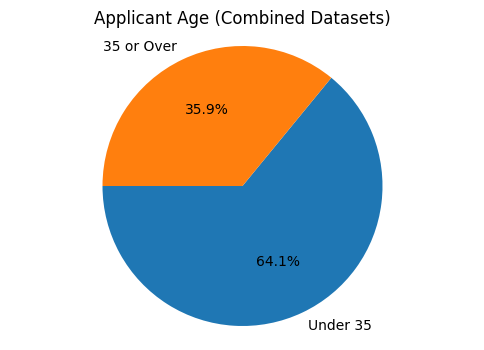

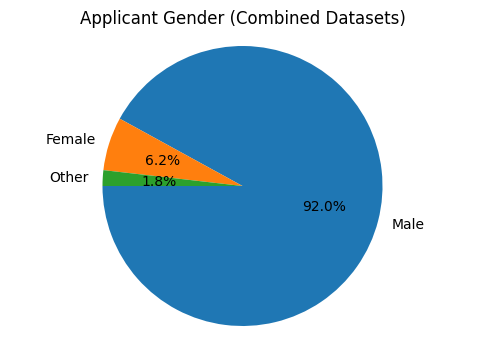

In [ ]:
# AGE
# Get combined dataset age columns and counts.
combined_age = combined_datasets['Age'].unique()
combined_age_counts = combined_datasets['Age'].value_counts()

# Plot combined dataset applicant age pie chart.
plt.figure(figsize = (6, 4))
plt.pie(combined_age_counts, labels = combined_age, autopct = "%1.1f%%", shadow = False, startangle = 180)
plt.axis("equal")
plt.title("Applicant Age (Combined Datasets)")
plt.show()


# GENDER
# Get combined dataset gender columns and counts.
combined_gender = combined_datasets['Gender'].unique()
combined_gender_counts = combined_datasets['Gender'].value_counts()

# Plot combined dataset applicant age pie chart.
plt.figure(figsize = (6, 4))
plt.pie(combined_gender_counts, labels = combined_gender, autopct = "%1.1f%%", shadow = False, startangle = 180)
plt.axis("equal")
plt.title("Applicant Gender (Combined Datasets)")
plt.show()

**Interpretation:**
* Most applicants are male and most are under 35.

**Correlation Matrix for the Combined Dataset:**

In [ ]:
# One-hot encoding on the combined datasets so the values can be used in a correlation matrix.

# Make a deep copy of the combined datasets DataFrame to one-hot encode.
one_hot_encoded_combined_datasets = combined_datasets.copy(deep = True)

# Go through the age column and transform the data to binary. (True/1 if the applicant is under 35.)
def one_hot_age(row):
  if (row['Age'] == "Under 35"):
    return 1
  else:
    return 0

combined_datasets['Age'] = one_hot_encoded_combined_datasets.apply(one_hot_age, axis = 1)

# Rename the column appropriately.
one_hot_encoded_combined_datasets.rename(columns={'Age': 'Under 35'}, inplace = True)

# Go through the gender column and transform the data to binary. (True/1 if the applicant is male.)
def one_hot_gender(row):
  if (row['Gender'] == "Male"):
    return 1
  else:
    return 0

combined_datasets['Gender'] = one_hot_encoded_combined_datasets.apply(one_hot_gender, axis = 1)

# Rename the column appropriately.
one_hot_encoded_combined_datasets.rename(columns = {'Gender': 'Is Male'}, inplace = True)

# Print the first few rows of the one-hot encoded combined dataset.
one_hot_encoded_combined_datasets.head()

,Under 35,Is Male,Employed
0,1,1,0
1,1,1,1
2,1,1,0
3,1,1,0
4,0,1,0


          Under 35   Is Male  Employed
Under 35  1.000000  0.003321  0.032720
Is Male   0.003321  1.000000  0.064586
Employed  0.032720  0.064586  1.000000


Heatmap of Above Correlation Matrix:


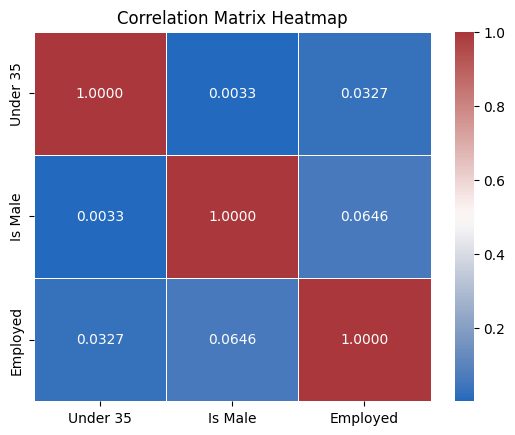

In [ ]:
# Create a correlation matrix for numeric columns in the first datset.
combined_correlation_matrix = one_hot_encoded_combined_datasets.corr(numeric_only = True)
print(combined_correlation_matrix)

import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap to visualize the correlation matrix.
print("\n\nHeatmap of Above Correlation Matrix:")
sns.heatmap(combined_correlation_matrix, annot = True, cmap = "vlag", fmt = ".4f", linewidths = 0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()

**Interpretation:**
* There is a slight positive correlation between employment and male applicants and those who are under 35. This might mean that young, male applicants are slightly advantaged in hiring decisions.
* However, we also found that most applicants are male and under 35, so in that regard this makes sense.

### **Preliminary Results (Also in Technical Memo)**

Our three analysis questions were:
* What are the characteristics/attributes of employable job applicants
* How does education level influence employment and salary?
* How does demographic information (age, gender, etc.) relate to the number of “computer skills” a person knows?

<br>

Through our analysis so far, we can draw some conclusions about what characteristics/attributes employable job applicants hold. When filtering our data to analyze demographics/skills of only employed applicants, we found most employed people were men, under 35, professional developers, and had an undergraduate education level. These people also had about 15-20 computer skills, compared to 10-15 for all applicants. Through our correlation matrix, we also found a slight positive correlation between employed and computer skills. Perhaps the number of computer skills an applicant reports is important in terms of employment. The education levels of the applicant beyond undergraduate education does not play as significant a role in determining the employability of a profile as we initially expected.

### **Next Steps (Also in Technical Memo)**

Next Steps: We can continue to analyze the data and answer our analysis questions by splitting/filtering the dataset. First, we will divide the dataset by education level and look at the average salary and employment status for these applicants. Then, we could divide the dataset by the number of computer skills and see what the demographics of the “top” applicants are. Another thing we wanted to look into was how demographic information relates (or doesn't) to the number of computer skills an applicant knows.